# Module 13: Statistics & Hypothesis Testing
## Objective: Proving our findings using mathematical rigor.

In this module, we transition from "Observing" data to "Testing" it. We will learn 
how to identify the distribution of our data and use **P-values** to validate 
our regional analysis.

### 1. Identifying Data Distributions
Understanding the "Generator" of your data helps you choose the right model. 
We use `scipy.stats` to simulate and visualize these patterns.

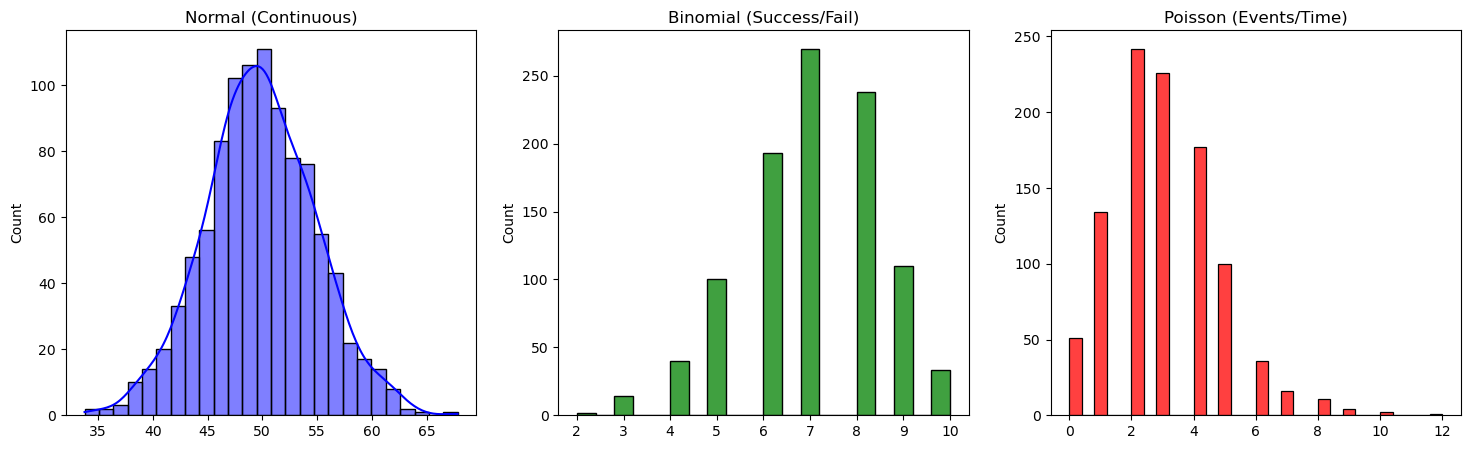

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Normal Distribution (Weights of local produce)
normal_data = stats.norm.rvs(loc=50, scale=5, size=1000)

# 2. Binomial Distribution (Success/Failure of 10 seeds, 1000 trials)
binomial_data = stats.binom.rvs(n=10, p=0.7, size=1000)

# 3. Poisson Distribution (Calls to a clinic per hour)
poisson_data = stats.poisson.rvs(mu=3, size=1000)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(normal_data, kde=True, ax=ax[0], color='blue').set_title("Normal (Continuous)")
sns.histplot(binomial_data, ax=ax[1], color='green').set_title("Binomial (Success/Fail)")
sns.histplot(poisson_data, ax=ax[2], color='red').set_title("Poisson (Events/Time)")
plt.show()

### 2. Is the difference "Real"?
We use a **T-Test** to compare the means of two groups. 

**Scenario**: Does a new fertilizer actually increase crop yield?
* $H_0$: The new fertilizer has no effect.
* $H_a$: The new fertilizer increases yield.

In [2]:
# Group A: Traditional Fertilizer (10 farms)
group_a = [20, 22, 19, 21, 20, 23, 18, 20, 21, 22]

# Group B: New Bio-Fertilizer (10 farms)
group_b = [25, 27, 24, 26, 25, 28, 23, 25, 26, 27]

# Perform independent T-Test
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. The fertilizer is effective!")
else:
    print("Conclusion: Fail to reject the Null. The difference could be luck.")

T-Statistic: -7.4261
P-Value: 0.0000
Conclusion: Reject the Null Hypothesis. The fertilizer is effective!


### 3. Business Intelligence: A/B Testing
A/B testing is a specific form of hypothesis testing used to optimize 
user experience or business outcomes. We compare "Conversion Rates" 
between two versions.

In [3]:
# Version A (Old Button): 1000 visitors, 50 clicks (5% conversion)
# Version B (New Button): 1000 visitors, 75 clicks (7.5% conversion)

from statsmodels.stats.proportion import proportions_ztest

count = np.array([50, 75])
nobs = np.array([1000, 1000])

z_stat, p_val = proportions_ztest(count, nobs)

print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Version B is significantly better. Deploy the new button!")

Z-Statistic: -2.3094
P-Value: 0.0209
Version B is significantly better. Deploy the new button!


### Student Exercise: The Clinic Efficiency Test
**Goal**: Prove if a new scheduling system reduced waiting times.
1. Generate two lists of 30 "Waiting Times" (in minutes).
    - **System A**: Mean = 45, Std = 10.
    - **System B**: Mean = 38, Std = 8.
2. Check if both datasets follow a **Normal Distribution** (use `stats.shapiro`).
3. Perform a **T-Test** to see if the 7-minute reduction is statistically significant.
4. If the $p$-value is $< 0.05$, write a Markdown summary explaining why the 
   clinic should adopt the new system.